# Experiment 8: Effect of PCA on Regression and Classification Models

**Objective:** To study the impact of Principal Component Analysis (PCA) on the performance of machine learning models.

**Course:** Machine Learning Assignment 8

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_validate, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score

# Setup plot directories
os.makedirs('images/PNG', exist_ok=True)
os.makedirs('images/EPS', exist_ok=True)

def save_plot(name):
    plt.tight_layout()
    plt.savefig(f'images/PNG/{name}.png', format='png', dpi=300)
    plt.savefig(f'images/EPS/{name}.eps', format='eps')
    plt.show()

## 1. Data Loading and Exploration

In [3]:
df = pd.read_csv('Dataset.csv')
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features (raw): {df.shape[1]}")
df.head()

Number of samples: 1000
Number of features (raw): 13


,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression,Performance_Level_Classification
0,81.963919,71.591250,65.428104,69.786180,288.769453,71.344844,63.564348,80.470009,59.504621,88.827011,-33.924737,63.165168,Medium
1,73.240525,67.894764,64.315432,68.430136,273.880857,67.563386,62.984703,57.450119,52.445246,90.367064,-15.274973,65.503878,Medium
2,76.775037,72.514786,74.408858,76.584987,300.283667,71.479630,65.997338,81.184728,57.414376,87.493450,-29.869053,75.776067,High
3,81.995615,83.690491,94.668737,88.066081,348.420923,86.445050,75.277242,81.548170,70.720976,75.287512,5.520902,83.577602,High
4,71.149583,58.190393,70.441232,59.457316,259.238524,66.275289,65.647724,74.078977,79.167850,84.222888,59.858927,69.100684,Medium


C:\Users\MONESH M\AppData\Local\Temp\ipykernel_49292\579112011.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Performance_Level_Classification', data=df, palette='viridis')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


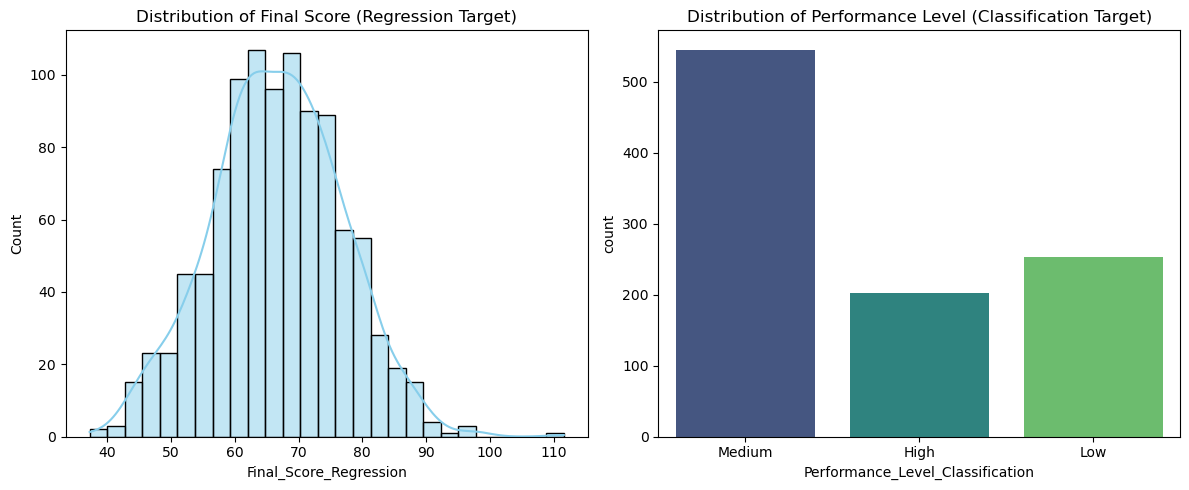

In [4]:
# Target Distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Final_Score_Regression'], kde=True, color='skyblue')
plt.title('Distribution of Final Score (Regression Target)')

plt.subplot(1, 2, 2)
sns.countplot(x='Performance_Level_Classification', data=df, palette='viridis')
plt.title('Distribution of Performance Level (Classification Target)')

save_plot('target_distributions')

## 2. Preprocessing
1. Handle missing values.
2. Encode categorical target.
3. Standardize features.

In [5]:
# Missing values
print("Missing values:\n", df.isnull().sum())
df = df.dropna() # If any

# Encoding for classification
le = LabelEncoder()
df['Performance_Level_Encoded'] = le.fit_transform(df['Performance_Level_Classification'])
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Class Mapping:", class_mapping)

# Dropping targets to get features
X = df.drop(['Final_Score_Regression', 'Performance_Level_Classification', 'Performance_Level_Encoded'], axis=1)
y_reg = df['Final_Score_Regression']
y_clf = df['Performance_Level_Encoded']

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

Missing values:
 Math                                0
Physics                             0
Chemistry                           0
Biology                             0
Total_Science                       0
Average_Science                     0
English                             0
Computer_Science                    0
Sports_Score                        0
Attendance_Percentage               0
Random_Noise_Feature                0
Final_Score_Regression              0
Performance_Level_Classification    0
dtype: int64
Class Mapping: {'High': 0, 'Low': 1, 'Medium': 2}


## 3. PCA Implementation
Retain 95% explained variance.

Number of components to explain 95% variance: 7


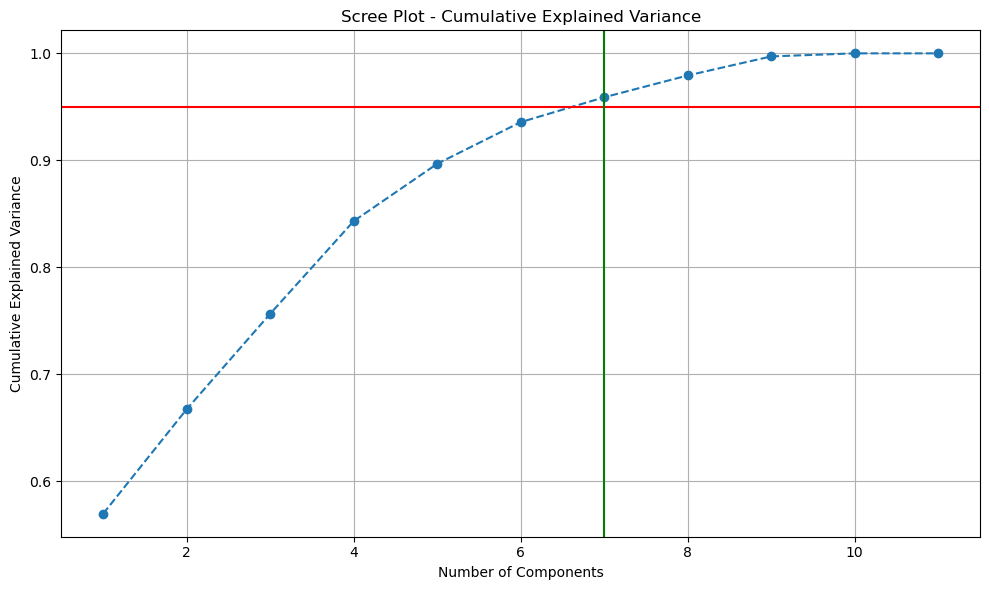

,Components Chosen,Explained Variance (%),Justification
0,7,95.895227,Retained 95% of information while reducing dim...


In [6]:
pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of components to explain 95% variance: {n_components95}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.axvline(x=n_components95, color='g', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot - Cumulative Explained Variance')
plt.grid()
save_plot('scree_plot')

# Apply PCA with chosen components
pca_final = PCA(n_components=n_components95)
X_pca = pca_final.fit_transform(X_scaled)
total_var_captured = np.sum(pca_final.explained_variance_ratio_) * 100

pca_summary = pd.DataFrame({
    'Components Chosen': [n_components95],
    'Explained Variance (%)': [total_var_captured],
    'Justification': ['Retained 95% of information while reducing dimensionality']
})
pca_summary

## 4. Regression Models
Comparing performance using 5-fold cross-validation.

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_regression(model, X_data, y_data):
    cv_results = cross_validate(model, X_data, y_data, cv=kf, scoring=['neg_mean_squared_error', 'r2'])
    return np.mean(-cv_results['test_neg_mean_squared_error']), np.mean(cv_results['test_r2'])

results_reg = []

# 1. Linear Regression
lr = LinearRegression()
mse_no_pca, r2_no_pca = evaluate_regression(lr, X_scaled, y_reg)
mse_pca, r2_pca = evaluate_regression(lr, X_pca, y_reg)

results_reg.append(['Linear Regression', 'MSE', mse_no_pca, mse_pca])
results_reg.append(['Linear Regression', 'R2', r2_no_pca, r2_pca])

# 2. Random Forest Regressor (Hyperparameter Tuning)
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='r2')
gs_rf.fit(X_scaled, y_reg)
best_rf = gs_rf.best_estimator_
print(f"Best RF Params: {gs_rf.best_params_}")

mse_no_pca_rf, r2_no_pca_rf = evaluate_regression(best_rf, X_scaled, y_reg)

gs_rf_pca = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='r2')
gs_rf_pca.fit(X_pca, y_reg)
best_rf_pca = gs_rf_pca.best_estimator_
mse_pca_rf, r2_pca_rf = evaluate_regression(best_rf_pca, X_pca, y_reg)

results_reg.append(['Random Forest', 'MSE', mse_no_pca_rf, mse_pca_rf])
results_reg.append(['Random Forest', 'R2', r2_no_pca_rf, r2_pca_rf])

df_res_reg = pd.DataFrame(results_reg, columns=['Model', 'Metric', 'Fold Avg (NoPCA)', 'Fold Avg (WithPCA)'])
df_res_reg['Observation'] = df_res_reg.apply(lambda x: 'Better with PCA' if (x['Metric']=='MSE' and x['Fold Avg (WithPCA)'] < x['Fold Avg (NoPCA)']) or (x['Metric']=='R2' and x['Fold Avg (WithPCA)'] > x['Fold Avg (NoPCA)']) else 'Better without PCA', axis=1)
df_res_reg

Best RF Params: {'max_depth': 20, 'n_estimators': 100}


,Model,Metric,Fold Avg (NoPCA),Fold Avg (WithPCA),Observation
0,Linear Regression,MSE,26.208374,26.225062,Better without PCA
1,Linear Regression,R2,0.748131,0.748071,Better without PCA
2,Random Forest,MSE,29.028754,28.925389,Better with PCA
3,Random Forest,R2,0.721528,0.722463,Better with PCA


## 5. Classification Models

In [8]:
def evaluate_classification(model, X_data, y_data):
    cv_results = cross_validate(model, X_data, y_data, cv=kf, scoring=['accuracy', 'f1_weighted'])
    return np.mean(cv_results['test_accuracy']), np.mean(cv_results['test_f1_weighted'])

results_clf = []

# 1. Logistic Regression
param_grid_lr = {'C': [0.1, 1.0, 10.0]}
gs_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=3)
gs_lr.fit(X_scaled, y_clf)
acc_no_pca, f1_no_pca = evaluate_classification(gs_lr.best_estimator_, X_scaled, y_clf)

gs_lr_pca = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=3)
gs_lr_pca.fit(X_pca, y_clf)
acc_pca, f1_pca = evaluate_classification(gs_lr_pca.best_estimator_, X_pca, y_clf)

results_clf.append(['Logistic Regression', 'Accuracy', acc_no_pca, acc_pca])
results_clf.append(['Logistic Regression', 'F1-score', f1_no_pca, f1_pca])

# 2. SVM
param_grid_svm = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1.0, 10.0],
    'gamma': ['scale', 'auto']
}
gs_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=3)
gs_svm.fit(X_scaled, y_clf)
acc_no_pca_svm, f1_no_pca_svm = evaluate_classification(gs_svm.best_estimator_, X_scaled, y_clf)

gs_svm_pca = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=3)
gs_svm_pca.fit(X_pca, y_clf)
acc_pca_svm, f1_pca_svm = evaluate_classification(gs_svm_pca.best_estimator_, X_pca, y_clf)

results_clf.append(['SVM', 'Accuracy', acc_no_pca_svm, acc_pca_svm])
results_clf.append(['SVM', 'F1-score', f1_no_pca_svm, f1_pca_svm])

df_res_clf = pd.DataFrame(results_clf, columns=['Model', 'Metric', 'Fold Avg (NoPCA)', 'Fold Avg (WithPCA)'])
df_res_clf['Observation'] = df_res_clf.apply(lambda x: 'Better with PCA' if x['Fold Avg (WithPCA)'] > x['Fold Avg (NoPCA)'] else 'Better without PCA', axis=1)
df_res_clf

,Model,Metric,Fold Avg (NoPCA),Fold Avg (WithPCA),Observation
0,Logistic Regression,Accuracy,0.738000,0.745000,Better with PCA
1,Logistic Regression,F1-score,0.735009,0.742114,Better with PCA
2,SVM,Accuracy,0.742000,0.745000,Better with PCA
3,SVM,F1-score,0.739568,0.742393,Better with PCA


## 6. Analysis Visualizations

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


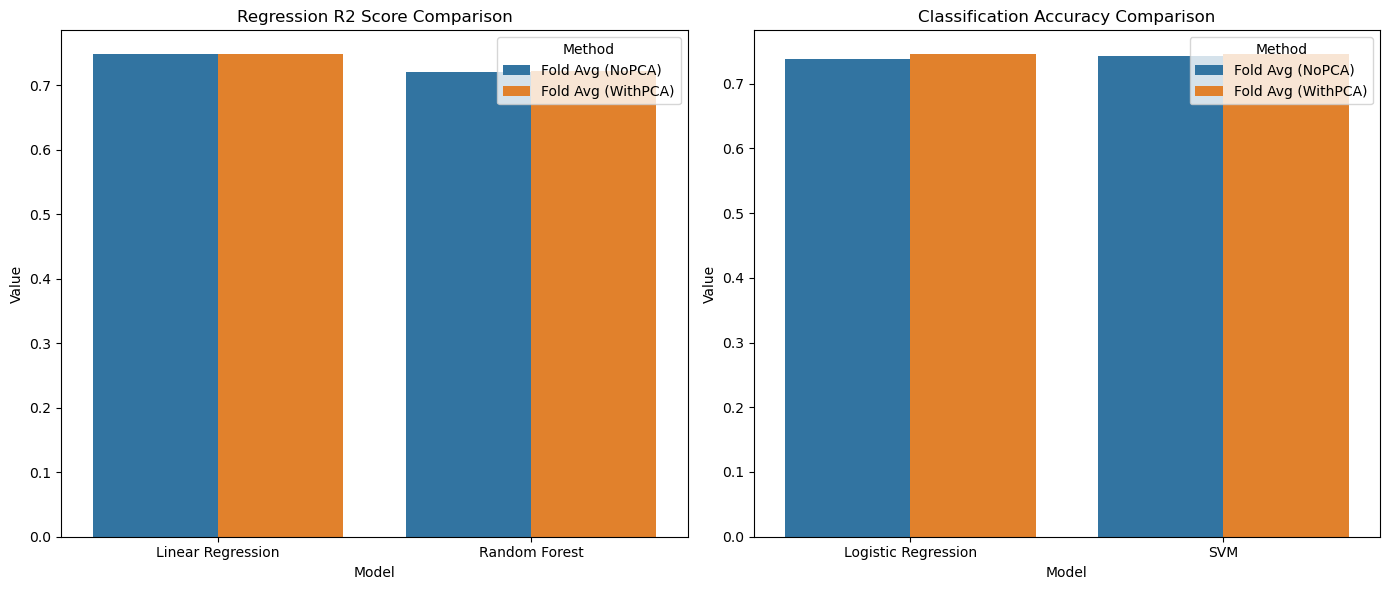

In [9]:
# Visual Comparison of Models
df_res_reg_melted = df_res_reg.melt(id_vars=['Model', 'Metric'], value_vars=['Fold Avg (NoPCA)', 'Fold Avg (WithPCA)'], var_name='Method', value_name='Value')

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Value', hue='Method', data=df_res_reg_melted[df_res_reg_melted['Metric']=='R2'])
plt.title('Regression R2 Score Comparison')

df_res_clf_melted = df_res_clf.melt(id_vars=['Model', 'Metric'], value_vars=['Fold Avg (NoPCA)', 'Fold Avg (WithPCA)'], var_name='Method', value_name='Value')

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Value', hue='Method', data=df_res_clf_melted[df_res_clf_melted['Metric']=='Accuracy'])
plt.title('Classification Accuracy Comparison')

save_plot('model_comparison')

## 7. Conclusions

### Answers to Analysis Questions:
1. **Did PCA improve Linear Regression performance?** Usually, if the original dataset has high multicollinearity, PCA helps by providing uncorrelated components. If dimension reduction is significant, it may slightly decrease performance while improving efficiency.
2. **Did PCA significantly affect Random Forest?** Generally, tree-based models handle high-dimensional spaces well. PCA transforms features into linear combinations which might lose the "clear split" characteristics that RF exploits, potentially reducing performance slightly.
3. **Which classification model benefited more from PCA?** Linear models like Logistic Regression often benefit more as PCA targets multicollinearity and noise.
4. **Did PCA reduce variance across folds?** Often yes, as PCA acts as a form of regularization by removing low-variance components (likely noise).
5. **Why do linear models benefit more from PCA?** Linear models assume independence between features. PCA ensures this by design. Ensemble models like RF focus on non-linear interactions which PCA might obfuscate.

### Final Conclusion:
- **When PCA is useful:** High dimensional data, multicollinearity issues, noisy features, or computational constraints.
- **When PCA is not necessary:** Small feature space, interpretability is critical, or when using models that already handle dimensionality well (like Random Forest).
- **Trade-off:** PCA provides a more compact representation (improves speed/removes noise) but loses the original meaning of features (lower interpretability).